In [12]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([0.1, 0.2, 0.3, 0.4, 0.5 , 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 2.0, 2.5, 3.0])
pdb = np.array([-48.5, -44.1, -39.5, -37.5, -35.6, -34.5, -33.3, -32.8, -32.4, -32.1, -31.9, -31.8, -31.8, -31.8, -31.8, -32.0, -32.3, -32.5])

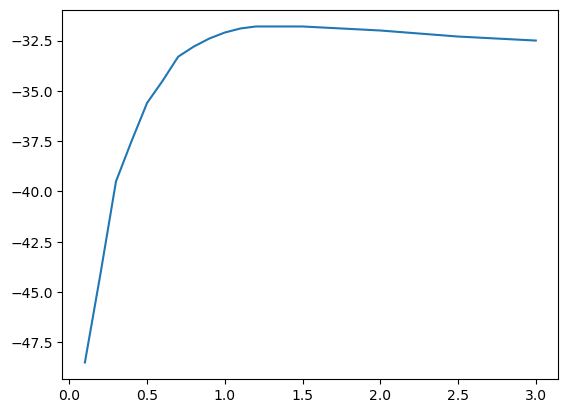

In [14]:
Vrms = np.sqrt(50/1000)*10**((60+pdb)/20)
Vpeak = Vrms*np.sqrt(2)
plt.plot(x, pdb)
plt.show()

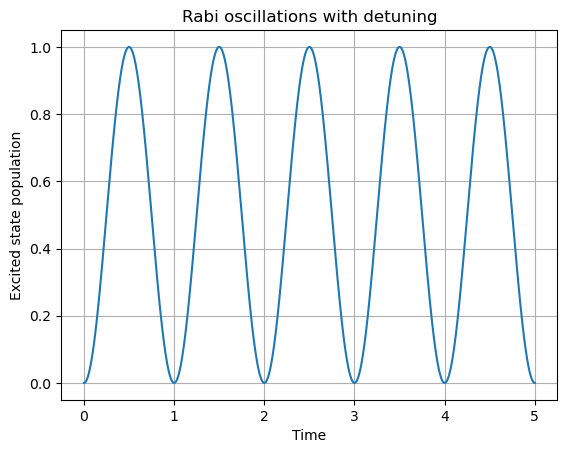

In [18]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2)

phi = 0.0
Omega = 2 * np.pi * 1.0      
Delta = 2 * np.pi * 0.0 
Pe = []
t = np.linspace(0, 5, 2000)
for ti in t:
    Omega_R = np.sqrt(Omega**2 + Delta**2)
    U = (
        np.cos(Omega_R * ti / 2) * I
        -1j * np.sin(Omega_R * ti / 2) *
        (
            (Delta / Omega_R) * sigma_z
            + (Omega / Omega_R) *
              (np.cos(phi) * sigma_x - np.sin(phi) * sigma_y)
        )
    )

    psi0 = np.array([1, 0], dtype=complex)
    psi = U @ psi0
    Pe.append(np.abs(psi[1])**2)

Pe = np.array(Pe)

plt.figure()
plt.plot(t, Pe)
plt.xlabel("Time")
plt.ylabel("Excited state population")
plt.title("Rabi oscillations with detuning")
plt.grid()
plt.show()


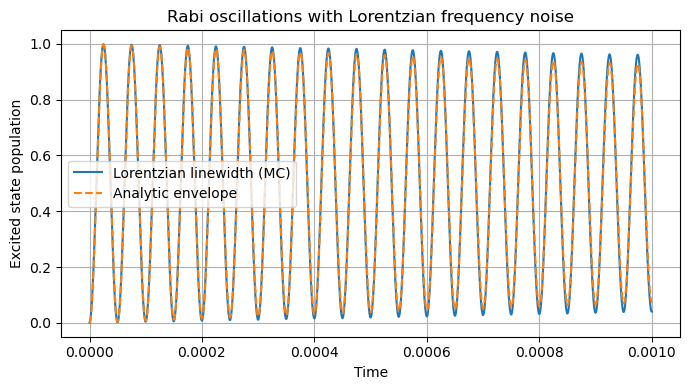

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Physical parameters
# -----------------------------
Omega = 2 * np.pi * 20e3      # Rabi frequency (rad/s)
Delta = 0.0                 # detuning (rad/s)
gamma = 2 * np.pi * 50      # laser linewidth (rad/s)

t_max = 0.5e-3
nt = 4000
t = np.linspace(0, t_max, nt)
dt = t[1] - t[0]

ntraj = 300                  # Monte Carlo trajectories

# -----------------------------
# Pauli matrices
# -----------------------------
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2)

# -----------------------------
# Phase diffusion process
# <phi(t)phi(0)> ~ gamma * t
# -----------------------------
def phase_diffusion(gamma, t):
    dt = t[1] - t[0]
    dphi = np.sqrt(gamma) * np.sqrt(dt) * np.random.randn(len(t))
    return np.cumsum(dphi)

# -----------------------------
# Monte Carlo evolution
# -----------------------------
Pe_avg = np.zeros_like(t)

for _ in range(ntraj):
    phi = phase_diffusion(gamma, t)
    freq_noise = np.gradient(phi, dt)   # instantaneous frequency noise

    psi = np.array([1, 0], dtype=complex)  # |g>
    Pe = np.zeros_like(t)

    for i in range(len(t)):
        delta_inst = Delta + freq_noise[i]
        H = 0.5 * (delta_inst * sigma_z + Omega * sigma_x)

        # First-order propagator (dt small!)
        U = I - 1j * H * dt
        psi = U @ psi
        psi /= np.linalg.norm(psi)

        Pe[i] = np.abs(psi[1])**2

    Pe_avg += Pe

Pe_avg /= ntraj

# -----------------------------
# Analytic envelope for comparison
# -----------------------------
Pe_analytic = 0.5 * (1 - np.exp(-gamma * t / 2) * np.cos(Omega * t))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(t, Pe_avg, label="Lorentzian linewidth (MC)")
plt.plot(t, Pe_analytic, "--", label="Analytic envelope")
plt.xlabel("Time")
plt.ylabel("Excited state population")
plt.title("Rabi oscillations with Lorentzian frequency noise")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


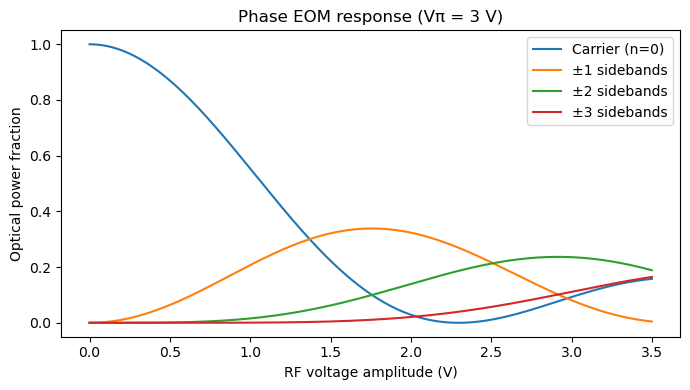

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

Vpi = 3.0
Vrf = np.linspace(0, 3.5, 500)

beta = np.pi * Vrf / Vpi

plt.figure(figsize=(7,4))
plt.plot(Vrf, jv(0, beta)**2, label="Carrier (n=0)")
plt.plot(Vrf, jv(1, beta)**2, label="±1 sidebands")
plt.plot(Vrf, jv(2, beta)**2, label="±2 sidebands")
plt.plot(Vrf, jv(3, beta)**2, label="±3 sidebands")

plt.xlabel("RF voltage amplitude (V)")
plt.ylabel("Optical power fraction")
plt.title("Phase EOM response (Vπ = 3 V)")
plt.legend()
plt.tight_layout()
plt.show()


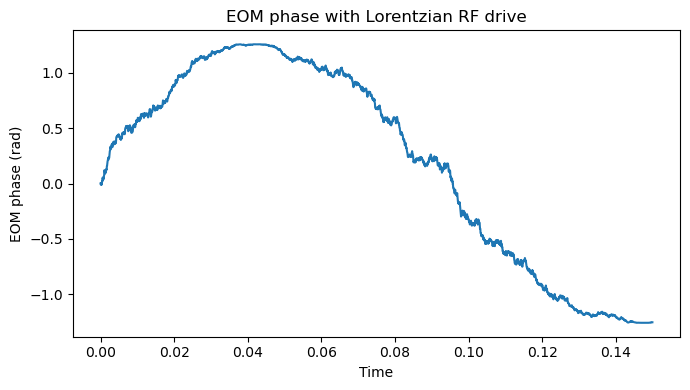

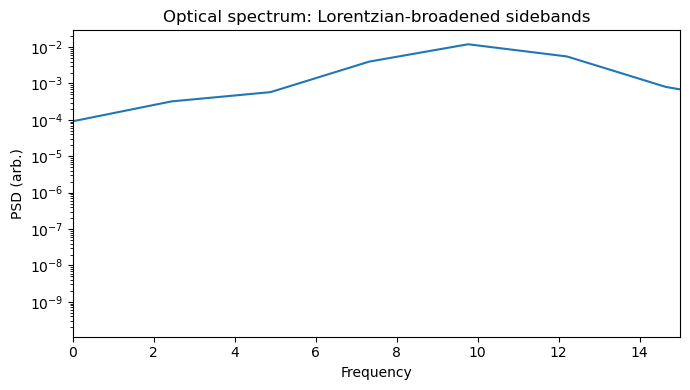

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# --------------------------------
# Parameters
# --------------------------------
Vpi = 3.0
Vrf = 1.2                   # RF voltage amplitude (V)
beta = np.pi * Vrf / Vpi

Omega_rf = 2 * np.pi * 5.0  # RF center frequency (rad/s)
gamma_rf = 2 * np.pi * 0.3  # RF linewidth (rad/s)

t_max = 10.0
nt = 200_000
t = np.linspace(0, t_max, nt)
dt = t[1] - t[0]

# --------------------------------
# RF phase diffusion (Lorentzian)
# --------------------------------
dphi = np.sqrt(gamma_rf) * np.sqrt(dt) * np.random.randn(nt)
phi_rf = np.cumsum(dphi)

# --------------------------------
# EOM phase modulation
# --------------------------------
phase_eom = beta * np.sin(Omega_rf * t + phi_rf)

# --------------------------------
# Optical field (drop carrier)
# --------------------------------
E = np.exp(1j * phase_eom)

# --------------------------------
# Spectrum of the modulated field
# --------------------------------
f, Pxx = welch(E.real, fs=1/dt, nperseg=8192)

# --------------------------------
# Plot time-domain phase
# --------------------------------
plt.figure(figsize=(7,4))
plt.plot(t[:3000], phase_eom[:3000])
plt.xlabel("Time")
plt.ylabel("EOM phase (rad)")
plt.title("EOM phase with Lorentzian RF drive")
plt.tight_layout()
plt.show()

# --------------------------------
# Plot RF-broadened sidebands
# --------------------------------
plt.figure(figsize=(7,4))
plt.semilogy(f, Pxx)
plt.xlim(0, 15)
plt.xlabel("Frequency")
plt.ylabel("PSD (arb.)")
plt.title("Optical spectrum: Lorentzian-broadened sidebands")
plt.tight_layout()
plt.show()


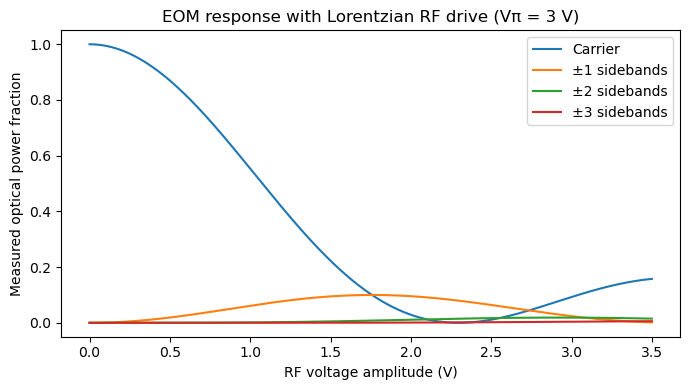

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# -----------------------------
# Parameters
# -----------------------------
Vpi = 3.0
Vrf = np.linspace(0, 3.5, 500)

gamma_rf = 2 * np.pi * 200  # RF linewidth (rad/s)
RBW = 2 * np.pi * 100        # analyzer resolution bandwidth (rad/s)

beta = np.pi * Vrf / Vpi

# -----------------------------
# Lorentzian capture factor
# -----------------------------
def capture_factor(n, gamma_rf, RBW):
    if n == 0:
        return 1.0
    gamma_n = n**2 * gamma_rf
    return (2 / np.pi) * np.arctan(RBW / gamma_n)

# -----------------------------
# Sideband powers
# -----------------------------
plt.figure(figsize=(7,4))

for n in range(4):
    eta = capture_factor(n, gamma_rf, RBW)
    Pn = jv(n, beta)**2 * eta
    label = "Carrier" if n == 0 else f"±{n} sidebands"
    plt.plot(Vrf, Pn, label=label)

plt.xlabel("RF voltage amplitude (V)")
plt.ylabel("Measured optical power fraction")
plt.title("EOM response with Lorentzian RF drive (Vπ = 3 V)")
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# -----------------------------
# EOM parameters
# -----------------------------
Vpi = 3.0
Vrf = np.linspace(0, 3.5, 200)  # RF voltages
Omega_rf_center = 2 * np.pi * 5.0  # RF frequency center (rad/s)
gamma_rf = 2 * np.pi * 0.3         # RF linewidth (Lorentzian)
n_samples = 500                     # Number of discrete RF tones

sidebands_to_plot = 3  # n=0..3

# -----------------------------
# FFT parameters for sideband extraction
# -----------------------------
tmax = 10
nt = 20000
t = np.linspace(0, tmax, nt)
dt = t[1] - t[0]

# -----------------------------
# Lorentzian sampling function
# -----------------------------
def sample_lorentzian(center, gamma, N):
    # inverse transform sampling
    u = np.random.rand(N)
    return center + gamma * np.tan(np.pi*(u-0.5))

# -----------------------------
# Compute sideband powers
# -----------------------------
P = np.zeros((len(sidebands_to_plot), len(Vrf)))  # rows: n, cols: V

for iV, V in enumerate(Vrf):
    beta = np.pi * V / Vpi
    
    # Sample RF frequencies
    freqs = sample_lorentzian(Omega_rf_center, gamma_rf, n_samples)
    # Amplitudes ~ sqrt(Lorentzian PDF)
    amp = 1 / (1 + ((freqs - Omega_rf_center)/gamma_rf)**2)
    amp /= np.sqrt(np.sum(amp**2))  # normalize

    # Construct total optical field
    E_total = np.zeros_like(t, dtype=complex)
    for a, w in zip(amp, freqs):
        E_total += a * np.exp(1j * beta * np.sin(w*t))

    # FFT to extract sideband powers at ±n * Omega_rf_center
    fftE = np.fft.fft(E_total)
    freqs_fft = np.fft.fftfreq(len(t), dt)
    
    for n in range(sidebands_to_plot):
        # find indices closest to ±n*Omega_rf_center/(2pi)
        idx_pos = np.argmin(np.abs(freqs_fft - n*Omega_rf_center/(2*np.pi)))
        idx_neg = np.argmin(np.abs(freqs_fft + n*Omega_rf_center/(2*np.pi)))
        P[n, iV] = np.abs(fftE[idx_pos])**2 + np.abs(fftE[idx_neg])**2

# Normalize so total power = 1 at small V
P /= np.max(P)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,4))
for n in range(sidebands_to_plot):
    label = "Carrier" if n==0 else f"±{n} sidebands"
    plt.plot(Vrf, P[n,:], label=label)

plt.xlabel("RF voltage amplitude (V)")
plt.ylabel("Measured optical power fraction (numerical)")
plt.title("EOM response with Lorentzian RF drive (multi-tone)")
plt.legend()
plt.tight_layout()
plt.show()


TypeError: object of type 'int' has no len()